# **Data Import & EDA**

In [ ]:
from google.colab import files
files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

!pip install kagglehub -q

import kagglehub
path = kagglehub.competition_download('GiveMeSomeCredit')
print("Path to dataset:", path)

import os
for f in os.listdir(path):
    print(f)

Saving kaggle.json to kaggle.json


100%|██████████| 5.16M/5.16M [00:01<00:00, 4.97MB/s]

Extracting files...


Path to dataset: /root/.cache/kagglehub/competitions/GiveMeSomeCredit
Data Dictionary.xls
sampleEntry.csv
cs-test.csv
cs-training.csv


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Sklearn - Classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Sklearn - Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, silhouette_score, davies_bouldin_score
)

# Imbalanced
from imblearn.over_sampling import SMOTE

# SHAP
import shap

# Model saving
import pickle
import os


In [ ]:
import pandas as pd
import numpy as np
import os

import kagglehub
path = kagglehub.competition_download('GiveMeSomeCredit')

df_raw = pd.read_csv(os.path.join(path, 'cs-training.csv'), index_col=0)

print("Shape:", df_raw.shape)
df_raw

Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [ ]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
print(pd.DataFrame({'Missing': missing, 'Persen (%)': missing_pct}))

                                      Missing  Persen (%)
SeriousDlqin2yrs                            0        0.00
RevolvingUtilizationOfUnsecuredLines        0        0.00
age                                         0        0.00
NumberOfTime30-59DaysPastDueNotWorse        0        0.00
DebtRatio                                   0        0.00
MonthlyIncome                           29731       19.82
NumberOfOpenCreditLinesAndLoans             0        0.00
NumberOfTimes90DaysLate                     0        0.00
NumberRealEstateLoansOrLines                0        0.00
NumberOfTime60-89DaysPastDueNotWorse        0        0.00
NumberOfDependents                       3924        2.62


In [ ]:
df_raw.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


Tidak Default (0): 139,974 (93.32%)
Default (1)      : 10,026 (6.68%)
Rasio imbalance  : 1 : 14.0


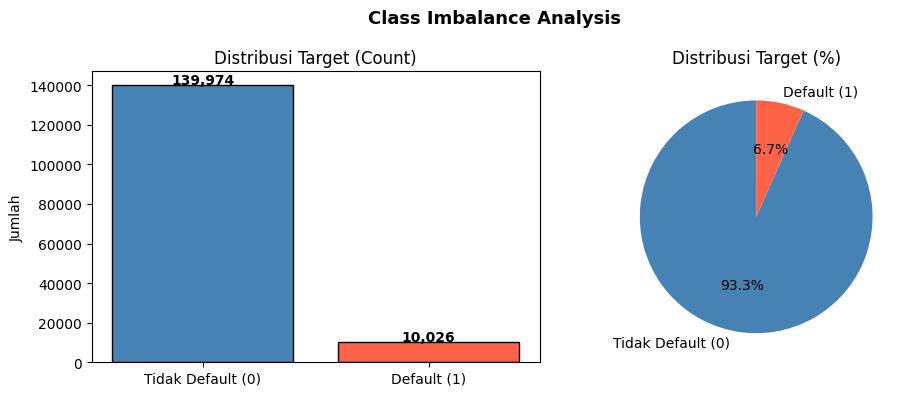

In [ ]:
# Distribusi target
target_counts = df_raw['SeriousDlqin2yrs'].value_counts()
target_pct = df_raw['SeriousDlqin2yrs'].value_counts(normalize=True).mul(100).round(2)

print(f"Tidak Default (0): {target_counts[0]:,} ({target_pct[0]}%)")
print(f"Default (1)      : {target_counts[1]:,} ({target_pct[1]}%)")
print(f"Rasio imbalance  : 1 : {round(target_counts[0]/target_counts[1], 1)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(['Tidak Default (0)', 'Default (1)'],
            target_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Distribusi Target (Count)')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values,
            labels=['Tidak Default (0)', 'Default (1)'],
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribusi Target (%)')

plt.suptitle('Class Imbalance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df_raw['MonthlyIncome'].fillna(df_raw['MonthlyIncome'].median(), inplace=True)
df_raw['NumberOfDependents'].fillna(df_raw['NumberOfDependents'].median(), inplace=True)

print(df_raw.isnull().sum())

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


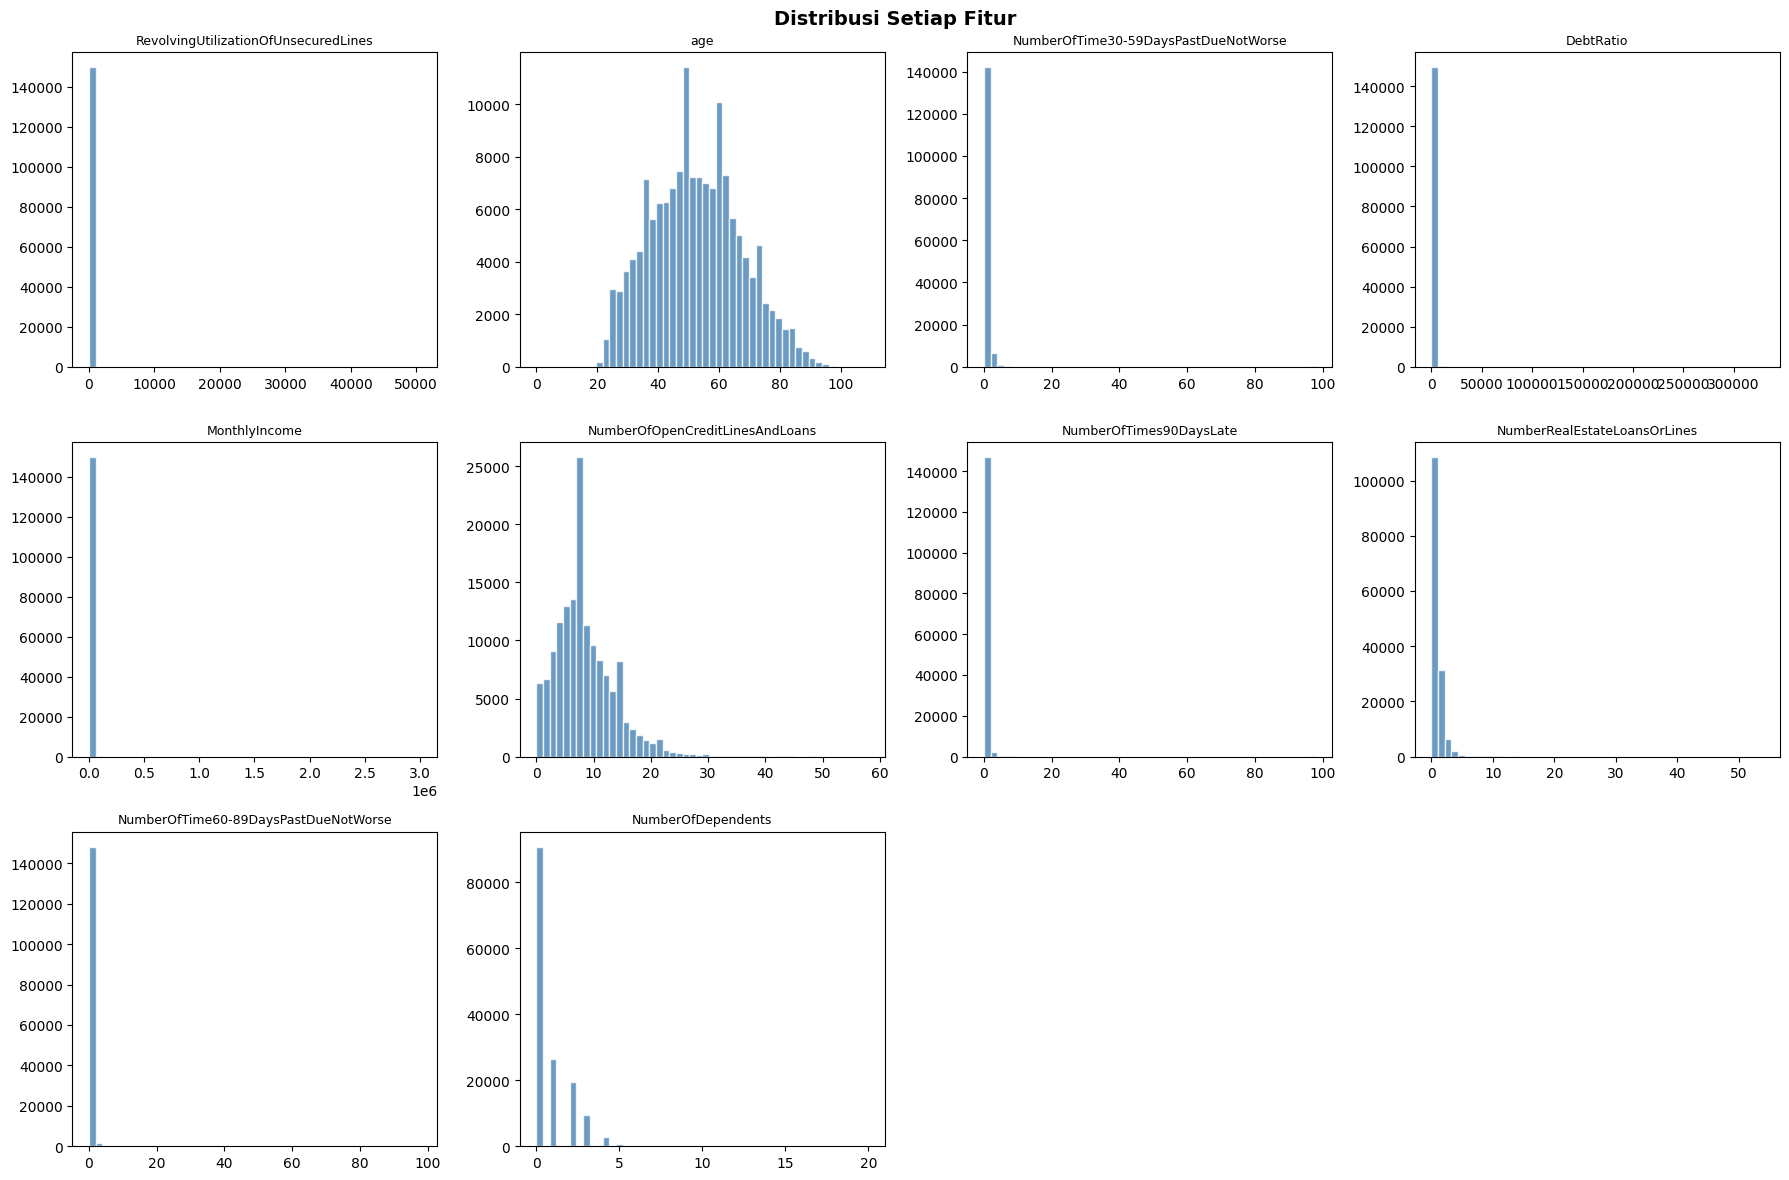

In [ ]:
# Distribusi semua fitur numerik
features = df_raw.drop('SeriousDlqin2yrs', axis=1).columns.tolist()

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df_raw[col].dropna(), bins=50, color='steelblue',
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

# Sembunyikan subplot kosong
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Setiap Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

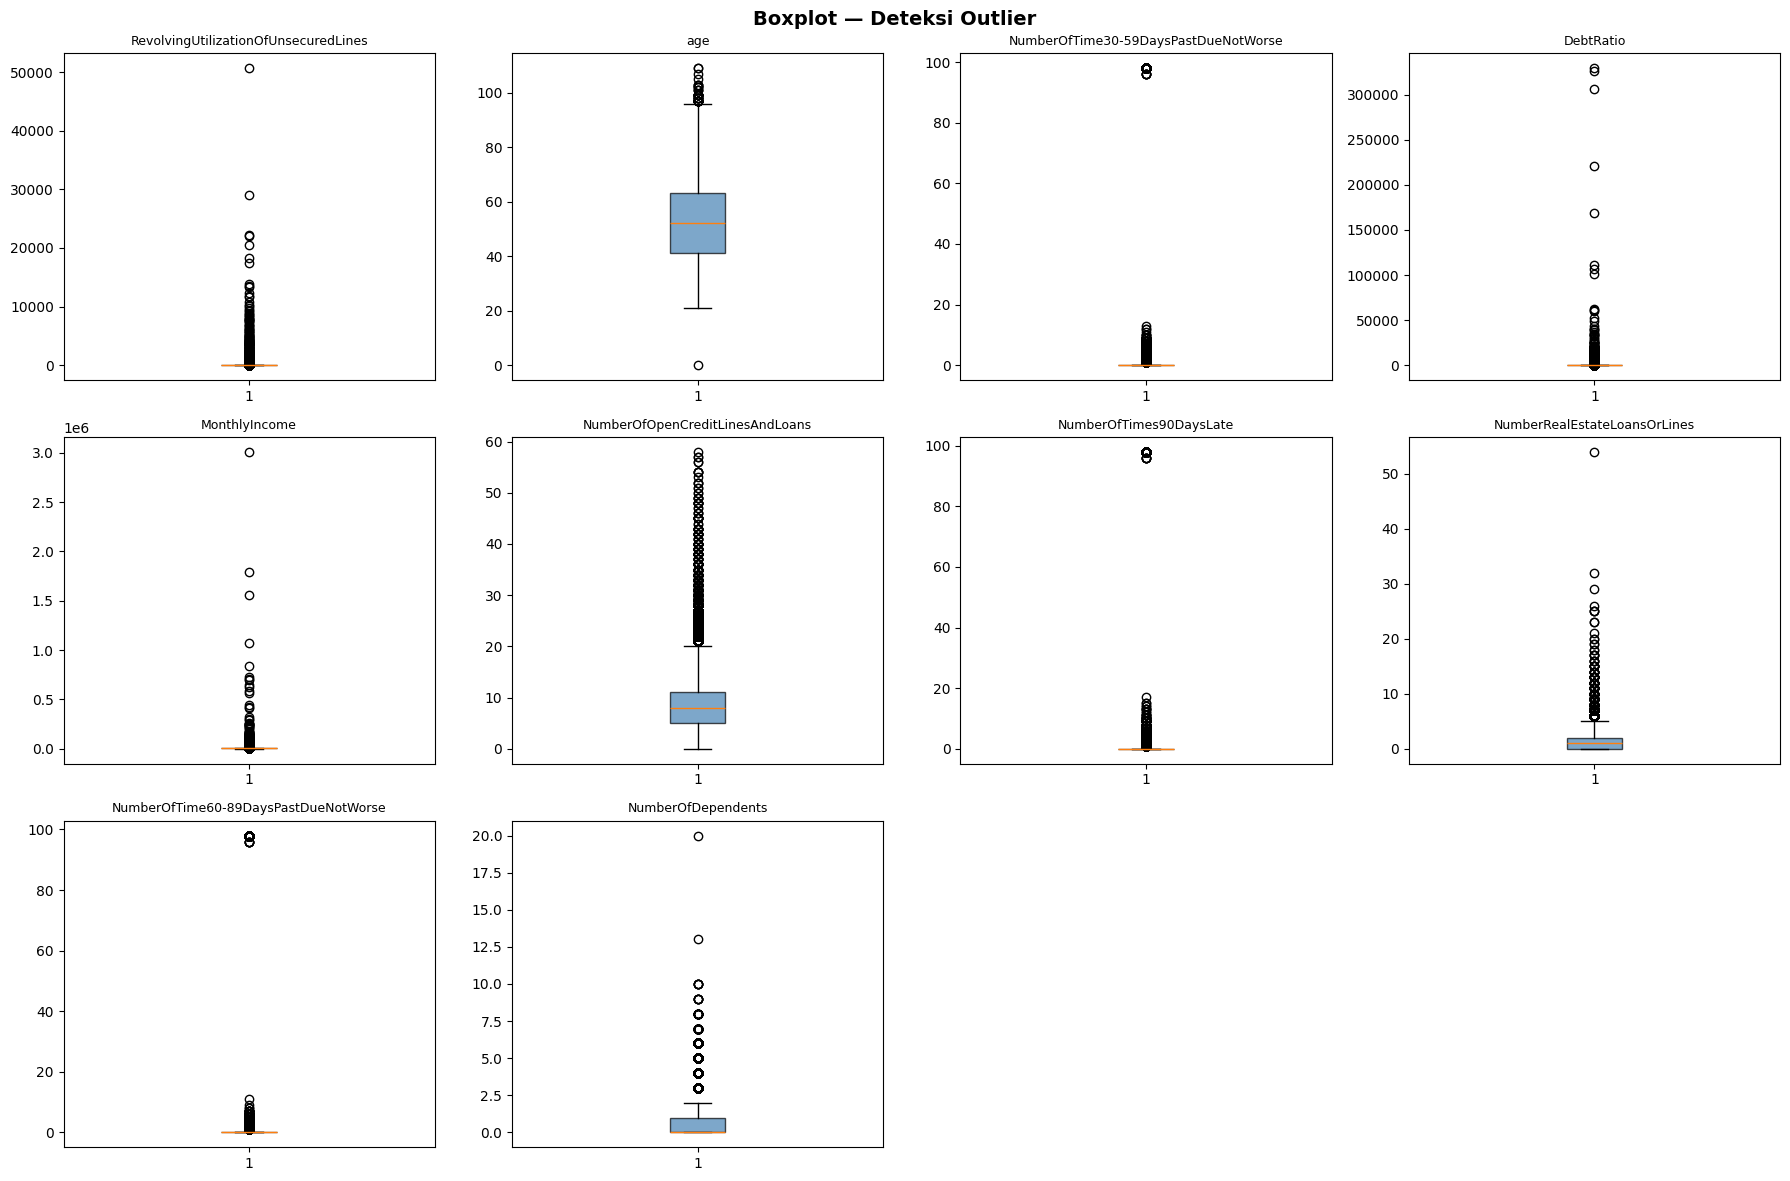

In [ ]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df_raw[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontsize=9)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot — Deteksi Outlier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

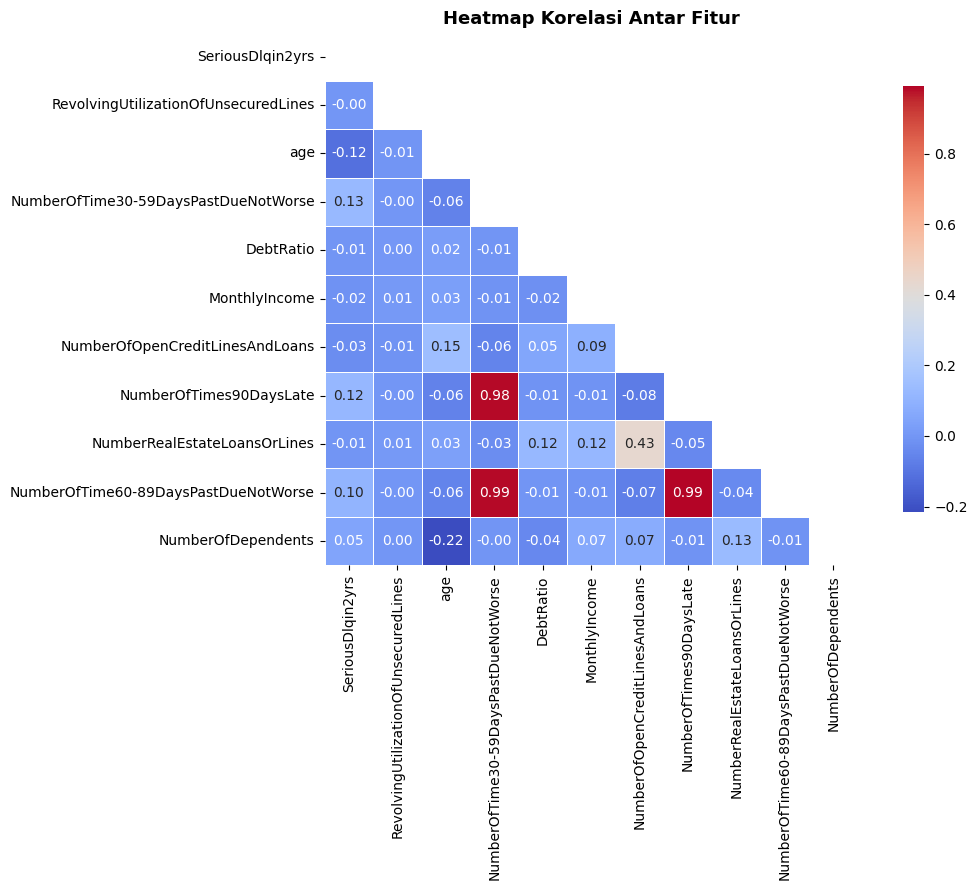

KORELASI TERHADAP TARGET
NumberOfTime30-59DaysPastDueNotWorse    0.1256
NumberOfTimes90DaysLate                 0.1172
NumberOfTime60-89DaysPastDueNotWorse    0.1023
NumberOfDependents                      0.0469
RevolvingUtilizationOfUnsecuredLines   -0.0018
NumberRealEstateLoansOrLines           -0.0070
DebtRatio                              -0.0076
MonthlyIncome                          -0.0172
NumberOfOpenCreditLinesAndLoans        -0.0297
age                                    -0.1154
Name: SeriousDlqin2yrs, dtype: float64


In [ ]:
# Heatmap korelasi
plt.figure(figsize=(12, 9))
corr_matrix = df_raw.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelasi terhadap target
print("KORELASI TERHADAP TARGET")
corr_target = df_raw.corr()['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs').sort_values(ascending=False)
print(corr_target.round(4))

# **2. Preprocessing**

In [ ]:
df = df_raw.copy()
print(f"Shape awal: {df_raw.shape}")

Shape awal: (150000, 11)


In [ ]:
# Imputasi dengan median (robust terhadap outlier)
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

print("Missing values setelah imputasi:")
print(df.isnull().sum())

Missing values setelah imputasi:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [ ]:
#TAHAP 1 — DOMAIN KNOWLEDGE CLIPPING

print(" SEBELUM DOMAIN CLIPPING ")
domain_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
print(df[domain_cols].describe().round(2))

# 1. RevolvingUtilizationOfUnsecuredLines
#    Definisi: rasio penggunaan kredit → HARUS antara 0–1
#    Nilai >1 = tidak masuk akal secara definisi
df['RevolvingUtilizationOfUnsecuredLines'] = \
    df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)

# 2. DebtRatio
#    Definisi: rasio utang/pendapatan → wajar maksimal 10
#    Nilai 300.000 = jelas data error
df['DebtRatio'] = df['DebtRatio'].clip(0, 10)

# 3. age
#    Minimum usia pengajuan kredit = 18 tahun
#    Maksimum yang masuk akal = 100 tahun
df['age'] = df['age'].clip(18, 100)

# 4. Fitur keterlambatan
#    Dalam rentang 2 tahun, max keterlambatan yang masuk akal = 20x
#    Nilai 96, 98 = data error
late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
for col in late_cols:
    df[col] = df[col].clip(0, 20)

print(" SETELAH DOMAIN CLIPPING ")
print(df[domain_cols].describe().round(2))

 SEBELUM DOMAIN CLIPPING 
       RevolvingUtilizationOfUnsecuredLines  DebtRatio        age  \
count                             150000.00  150000.00  150000.00   
mean                                   6.05     353.01      52.30   
std                                  249.76    2037.82      14.77   
min                                    0.00       0.00       0.00   
25%                                    0.03       0.18      41.00   
50%                                    0.15       0.37      52.00   
75%                                    0.56       0.87      63.00   
max                                50708.00  329664.00     109.00   

       NumberOfTime30-59DaysPastDueNotWorse  \
count                             150000.00   
mean                                   0.42   
std                                    4.19   
min                                    0.00   
25%                                    0.00   
50%                                    0.00   
75%                    

In [ ]:
# TAHAP 2 — IQR CAPPING

def iqr_capping(df, columns, multiplier=3.0):

    df_capped = df.copy()
    summary = []

    for col in columns:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR

        n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
        df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

        summary.append({
            'Fitur'          : col,
            'Q1'             : round(Q1, 2),
            'Q3'             : round(Q3, 2),
            'Batas Bawah'    : round(lower, 2),
            'Batas Atas'     : round(upper, 2),
            'Jumlah Ter-cap' : n_outlier
        })

    return df_capped, pd.DataFrame(summary)


# Fitur yang di-cap dengan IQR
# (tidak punya batas logis yang pasti dari domain knowledge)
iqr_cols = [
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents'
]

df, iqr_summary = iqr_capping(df, iqr_cols, multiplier=3.0)

print("RINGKASAN IQR CAPPING" )
print(iqr_summary.to_string(index=False))

RINGKASAN IQR CAPPING
                          Fitur     Q1     Q3  Batas Bawah  Batas Atas  Jumlah Ter-cap
                  MonthlyIncome 3903.0 7400.0      -6588.0     17891.0            3157
NumberOfOpenCreditLinesAndLoans    5.0   11.0        -13.0        29.0             442
   NumberRealEstateLoansOrLines    0.0    2.0         -6.0         8.0             209
             NumberOfDependents    0.0    1.0         -3.0         4.0             991


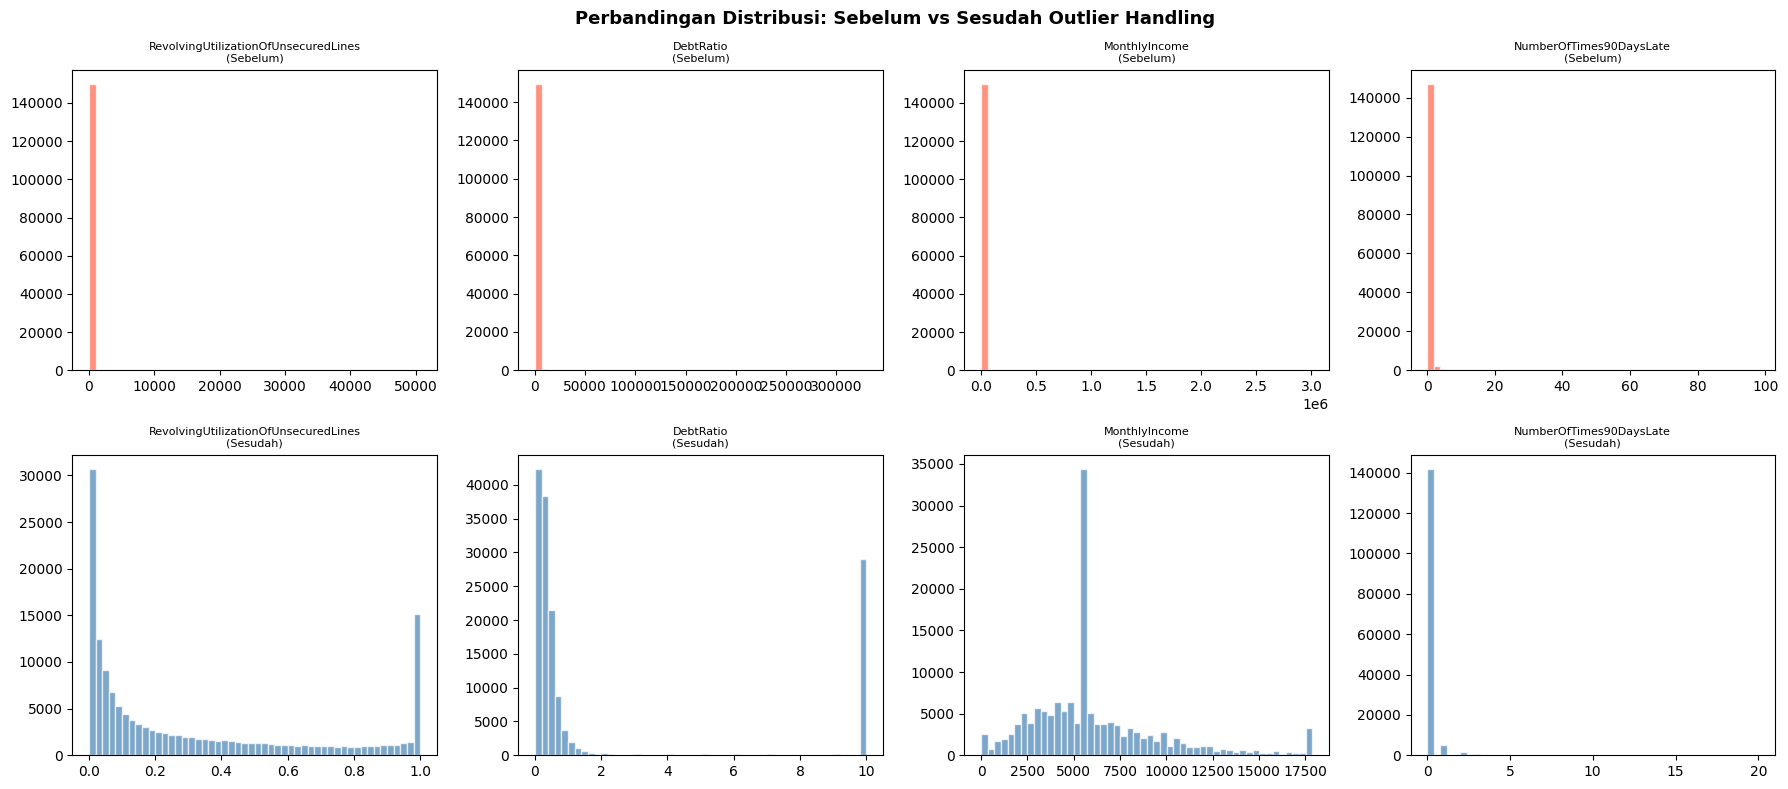

 RINGKASAN OUTLIER HANDLING 
Shape awal  : (150000, 11)
Shape akhir : (150000, 11)
Data hilang : 0 baris (strategi capping, bukan dropping)


In [ ]:
# Visualisasi perbandingan sebelum vs sesudah outlier handling
check_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfTimes90DaysLate'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(check_cols):
    # Sebelum (dari df_raw)
    axes[0, i].hist(df_raw[col].dropna(), bins=50,
                    color='tomato', alpha=0.7, edgecolor='white')
    axes[0, i].set_title(f'{col}\n(Sebelum)', fontsize=8)

    # Sesudah
    axes[1, i].hist(df[col], bins=50,
                    color='steelblue', alpha=0.7, edgecolor='white')
    axes[1, i].set_title(f'{col}\n(Sesudah)', fontsize=8)

plt.suptitle('Perbandingan Distribusi: Sebelum vs Sesudah Outlier Handling',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(" RINGKASAN OUTLIER HANDLING ")
print(f"Shape awal  : {df_raw.shape}")
print(f"Shape akhir : {df.shape}")
print(f"Data hilang : 0 baris (strategi capping, bukan dropping)")

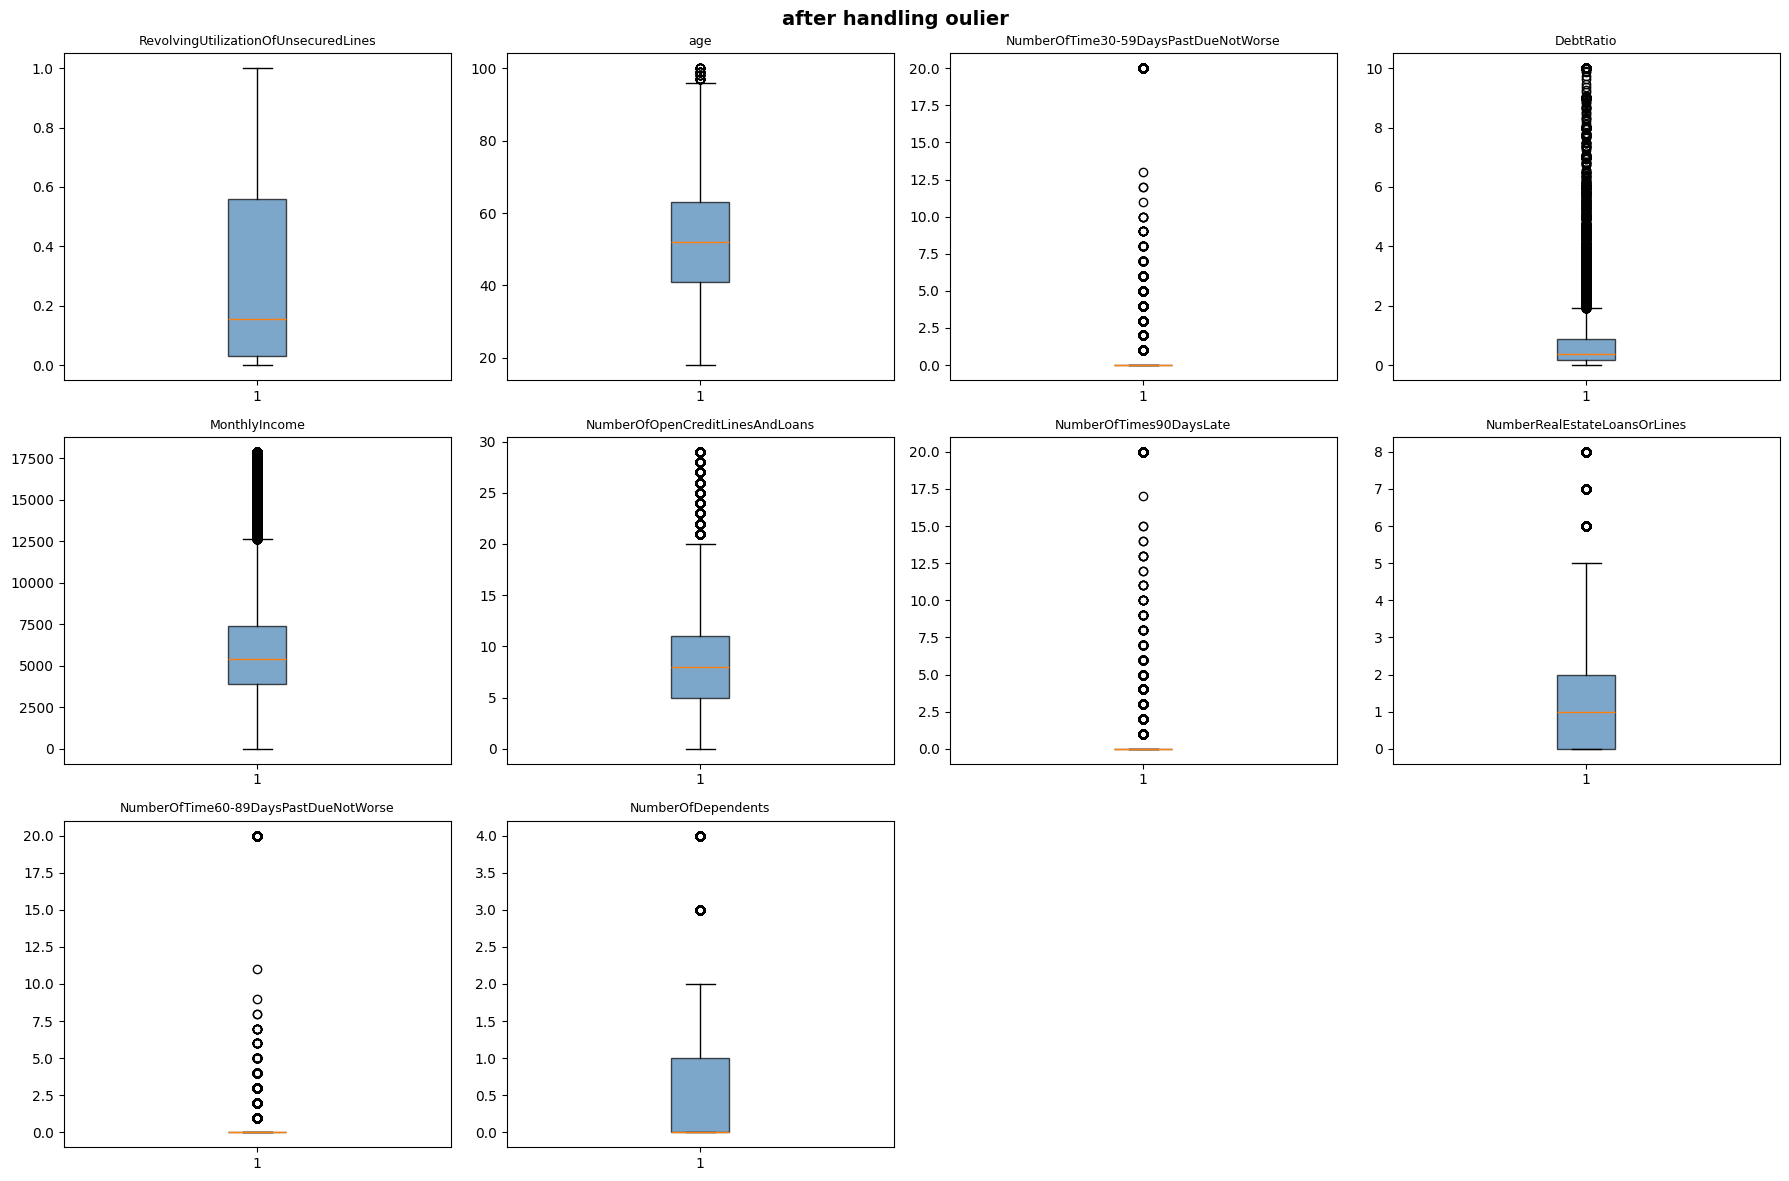

In [ ]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontsize=9)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('after handling oulier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **3. Feature Engineering**

In [ ]:
# Total keterlambatan semua kategori
df['TotalLatePayments'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)

# Age group (binning usia)
df['AgeGroup'] = pd.cut(df['age'],
                         bins=[0, 30, 45, 60, 100],
                         labels=[0, 1, 2, 3]).astype(int)

# Income per dependent (pendapatan per tanggungan)
df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

print(f"Total fitur sekarang: {df.shape[1]}")
df[['TotalLatePayments', 'AgeGroup', 'IncomePerDependent']].describe().round(2)

Total fitur sekarang: 14


,TotalLatePayments,AgeGroup,IncomePerDependent
count,150000.00,150000.00,150000.00
mean,0.51,1.89,4380.60
std,2.75,0.92,3019.61
min,0.00,0.00,0.00
25%,0.00,1.00,2161.00
50%,0.00,2.00,4000.00
75%,0.00,3.00,5400.00
max,60.00,3.00,17891.00


In [ ]:
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

=== HASIL SMOTE ===
Sebelum SMOTE: {0: np.int64(111979), 1: np.int64(8021)}
Setelah SMOTE: {0: np.int64(111979), 1: np.int64(111979)}


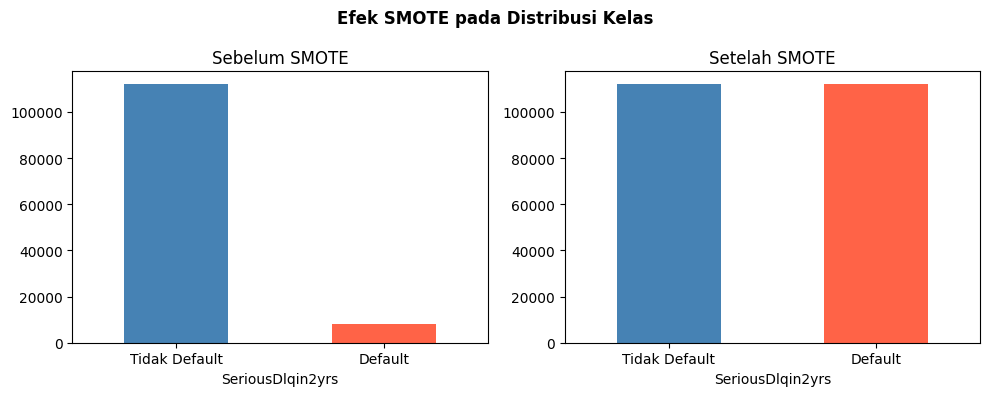

In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("=== HASIL SMOTE ===")
print(f"Sebelum SMOTE: {dict(y_train.value_counts())}")
print(f"Setelah SMOTE: {dict(pd.Series(y_train_resampled).value_counts())}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], title='Sebelum SMOTE')
pd.Series(y_train_resampled).value_counts().plot(kind='bar', ax=axes[1],
    color=['steelblue', 'tomato'], title='Setelah SMOTE')
axes[0].set_xticklabels(['Tidak Default', 'Default'], rotation=0)
axes[1].set_xticklabels(['Tidak Default', 'Default'], rotation=0)
plt.suptitle('Efek SMOTE pada Distribusi Kelas', fontweight='bold')
plt.tight_layout()
plt.show()

# **4. Classification Modeling**

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    auc   = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)

    result = {
        'Model'    : model_name,
        'AUC-ROC'  : round(auc, 4),
        'Accuracy' : round(report['accuracy'], 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall'   : round(report['1']['recall'], 4),
        'F1-Score' : round(report['1']['f1-score'], 4),
    }

    print(f"\n{'='*50}")
    print(f"  MODEL: {model_name}")
    print(f"{'='*50}")
    print(f"  AUC-ROC   : {result['AUC-ROC']}")
    print(f"  Accuracy  : {result['Accuracy']}")
    print(f"  Precision : {result['Precision']}")
    print(f"  Recall    : {result['Recall']}")
    print(f"  F1-Score  : {result['F1-Score']}")
    print(classification_report(y_test, y_pred))

    return result, y_prob

results_clf = []  # Menyimpan semua hasil
roc_data    = {}  # Menyimpan data ROC curve

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_resampled, y_train_resampled)

res_lr, prob_lr = evaluate_model(lr, X_test_scaled, y_test, 'Logistic Regression')
results_clf.append(res_lr)
roc_data['Logistic Regression'] = prob_lr


  MODEL: Logistic Regression
  AUC-ROC   : 0.8556
  Accuracy  : 0.7865
  Precision : 0.2042
  Recall    : 0.7576
  F1-Score  : 0.3217
              precision    recall  f1-score   support

           0       0.98      0.79      0.87     27995
           1       0.20      0.76      0.32      2005

    accuracy                           0.79     30000
   macro avg       0.59      0.77      0.60     30000
weighted avg       0.93      0.79      0.84     30000



In [ ]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, random_state=42)
dt.fit(X_train_resampled, y_train_resampled)

res_dt, prob_dt = evaluate_model(dt, X_test_scaled, y_test, 'Decision Tree')
results_clf.append(res_dt)
roc_data['Decision Tree'] = prob_dt


  MODEL: Decision Tree
  AUC-ROC   : 0.8526
  Accuracy  : 0.8354
  Precision : 0.2441
  Recall    : 0.6978
  F1-Score  : 0.3617
              precision    recall  f1-score   support

           0       0.98      0.85      0.91     27995
           1       0.24      0.70      0.36      2005

    accuracy                           0.84     30000
   macro avg       0.61      0.77      0.63     30000
weighted avg       0.93      0.84      0.87     30000



In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=7, min_samples_leaf=10, max_features='sqrt',
                             random_state=42, n_jobs=-1)
rf.fit(X_train_resampled, y_train_resampled)

res_rf, prob_rf = evaluate_model(rf, X_test_scaled, y_test, 'Random Forest')
results_clf.append(res_rf)
roc_data['Random Forest'] = prob_rf


  MODEL: Random Forest
  AUC-ROC   : 0.8646
  Accuracy  : 0.8305
  Precision : 0.2438
  Recall    : 0.7312
  F1-Score  : 0.3657
              precision    recall  f1-score   support

           0       0.98      0.84      0.90     27995
           1       0.24      0.73      0.37      2005

    accuracy                           0.83     30000
   macro avg       0.61      0.78      0.63     30000
weighted avg       0.93      0.83      0.87     30000



In [ ]:
xgb = XGBClassifier(
    n_estimators=100, max_depth=3,
    learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=2.0,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb.fit(X_train_resampled, y_train_resampled)

res_xgb, prob_xgb = evaluate_model(xgb, X_test_scaled, y_test, 'XGBoost')
results_clf.append(res_xgb)
roc_data['XGBoost'] = prob_xgb


  MODEL: XGBoost
  AUC-ROC   : 0.8624
  Accuracy  : 0.8268
  Precision : 0.2406
  Recall    : 0.7382
  F1-Score  : 0.3629
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     27995
           1       0.24      0.74      0.36      2005

    accuracy                           0.83     30000
   macro avg       0.61      0.79      0.63     30000
weighted avg       0.93      0.83      0.86     30000



In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=100, max_depth=3,
    learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.5, reg_lambda=2.0,
    min_child_samples=30,
    random_state=42, n_jobs=-1
)

lgbm.fit(X_train_resampled, y_train_resampled)

res_lgbm, prob_lgbm = evaluate_model(
    lgbm,
    X_test_scaled,
    y_test,
    'LightGBM'
)

results_clf.append(res_lgbm)
roc_data['LightGBM'] = prob_lgbm

[LightGBM] [Info] Number of positive: 111979, number of negative: 111979
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029414 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3307
[LightGBM] [Info] Number of data points in the train set: 223958, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

TABEL PERBANDINGAN MODEL CLASSIFICATION 
                     AUC-ROC  Accuracy  Precision  Recall  F1-Score
Model                                                              
Logistic Regression   0.8556    0.7865     0.2042  0.7576    0.3217
Decision Tree         0.8526    0.8354     0.2441  0.6978    0.3617
Random Forest         0.8646    0.8305     0.2438  0.7312    0.3657
XGBoost               0.8624    0.8268     0.2406  0.7382    0.3629
LightGBM              0.8627    0.8262     0.2394  0.7352    0.3611


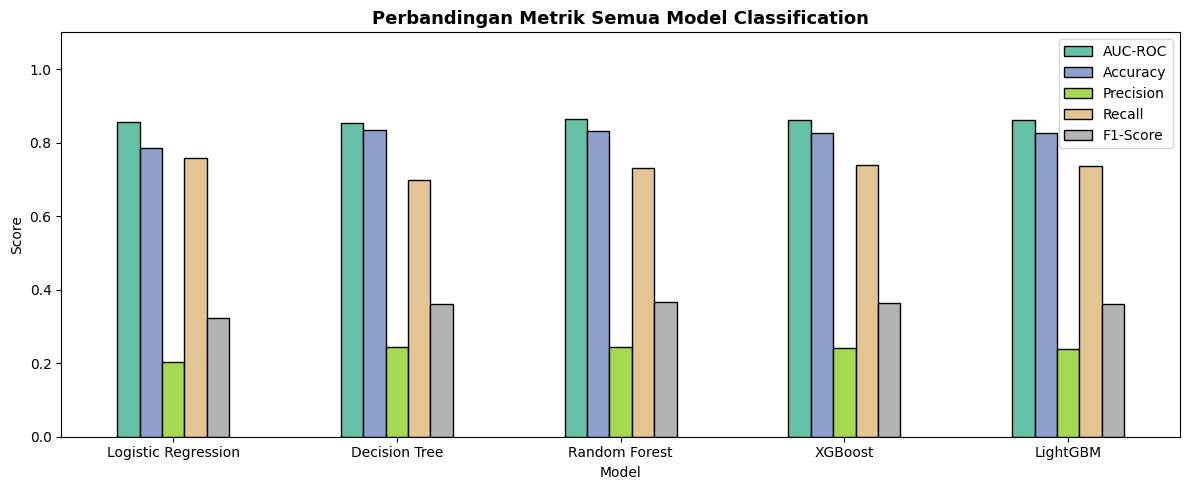


 MODEL TERBAIK: Random Forest
   AUC-ROC: 0.8646


In [ ]:
# Tabel perbandingan
results_df = pd.DataFrame(results_clf).set_index('Model')
print("TABEL PERBANDINGAN MODEL CLASSIFICATION ")
print(results_df.to_string())

# Visualisasi bar chart perbandingan
fig, ax = plt.subplots(figsize=(12, 5))
results_df[['AUC-ROC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', ax=ax, colormap='Set2', edgecolor='black'
)
ax.set_title('Perbandingan Metrik Semua Model Classification', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# Highlight model terbaik
best_model_name = results_df['AUC-ROC'].idxmax()
print(f"\n MODEL TERBAIK: {best_model_name}")
print(f"   AUC-ROC: {results_df.loc[best_model_name, 'AUC-ROC']}")

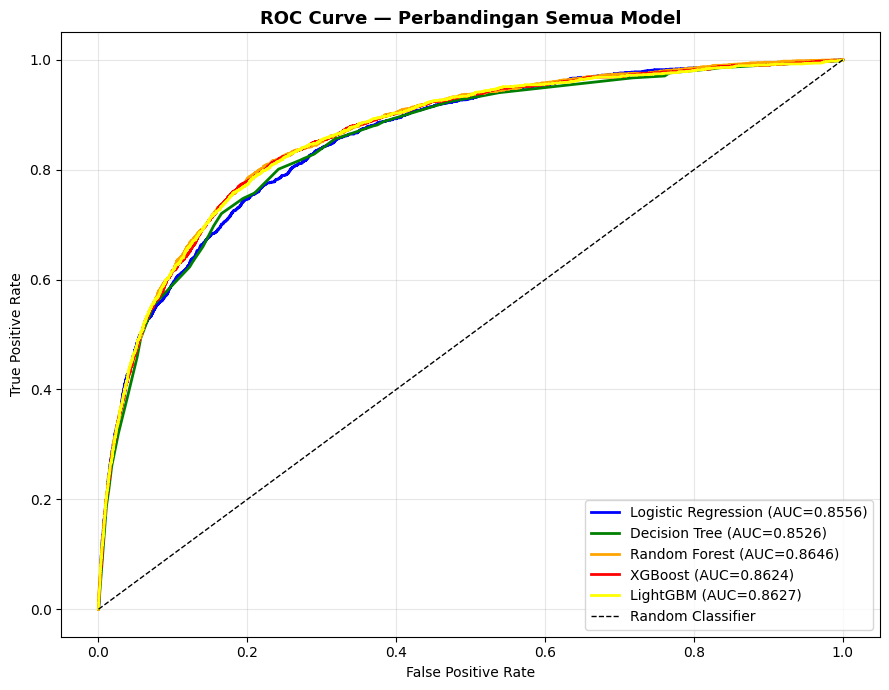

In [ ]:
plt.figure(figsize=(9, 7))
colors = ['blue', 'green', 'orange', 'red', 'yellow']

for (name, prob), color in zip(roc_data.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})',
             color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Perbandingan Semua Model', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

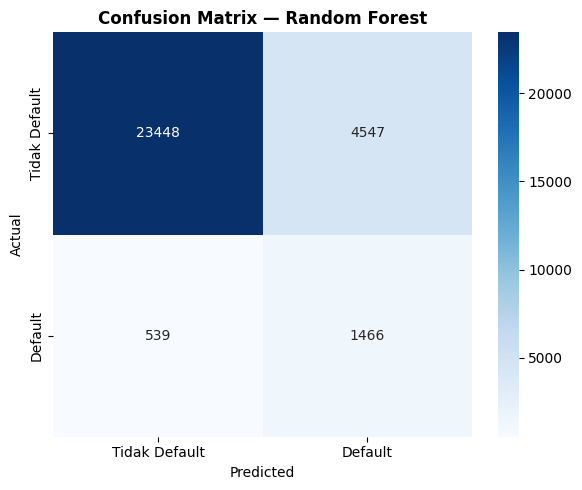

In [ ]:
model_map = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb,
    'LightGBM': lgbm
}

best_clf = model_map[best_model_name]
y_pred_best = best_clf.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Default', 'Default'],
            yticklabels=['Tidak Default', 'Default'])
plt.title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

                     Train AUC  Test AUC     Gap Status
Model                                                  
Logistic Regression     0.8464    0.8556 -0.0092     OK
Decision Tree           0.8843    0.8526  0.0317     OK
Random Forest           0.8938    0.8646  0.0292     OK
XGBoost                 0.8999    0.8624  0.0374     OK
LightGBM                0.9029    0.8627  0.0402     OK


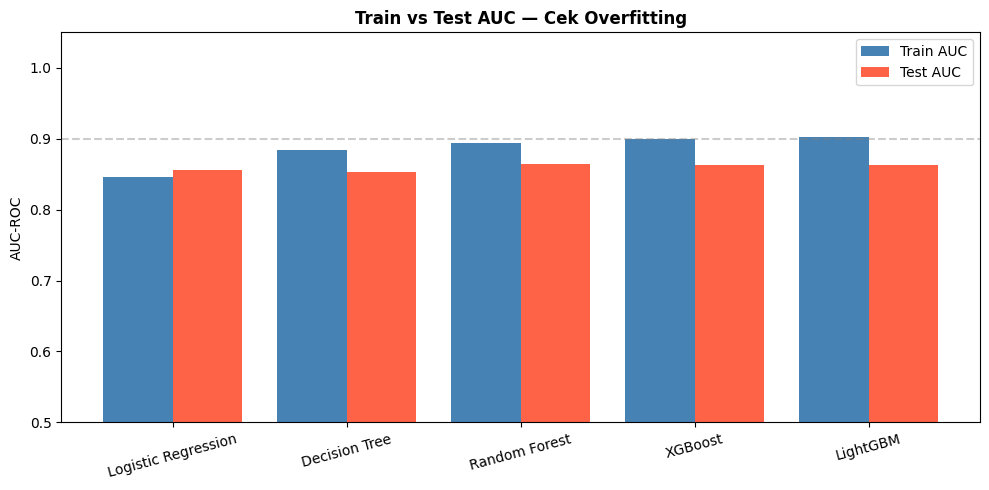

In [ ]:
model_map = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb,
    'LightGBM': lgbm
}

overfit_rows = []

for name, model in model_map.items():
    # Train score (pakai data resampled — sama seperti waktu fit)
    train_prob = model.predict_proba(X_train_resampled)[:, 1]
    train_auc  = roc_auc_score(y_train_resampled, train_prob)

    # Test score
    test_prob  = model.predict_proba(X_test_scaled)[:, 1]
    test_auc   = roc_auc_score(y_test, test_prob)

    gap = train_auc - test_auc
    status = 'Overfit' if gap > 0.05 else 'OK'

    overfit_rows.append({
        'Model'       : name,
        'Train AUC'   : round(train_auc, 4),
        'Test AUC'    : round(test_auc, 4),
        'Gap'         : round(gap, 4),
        'Status'      : status
    })

overfit_df = pd.DataFrame(overfit_rows).set_index('Model')
print(overfit_df.to_string())

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(overfit_df))
ax.bar([i - 0.2 for i in x], overfit_df['Train AUC'], width=0.4,
       label='Train AUC', color='steelblue')
ax.bar([i + 0.2 for i in x], overfit_df['Test AUC'],  width=0.4,
       label='Test AUC',  color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(overfit_df.index, rotation=15)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('AUC-ROC')
ax.set_title('Train vs Test AUC — Cek Overfitting', fontweight='bold')
ax.legend()
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.4, label='ref 0.9')
plt.tight_layout()
plt.show()

In [ ]:

model_map = {
    'Logistic Regression': lr,
    'Decision Tree':       dt,
    'Random Forest':       rf,
    'XGBoost':             xgb,
    'LightGBM':            lgbm
}

rows = []
for name, model in model_map.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)

    rows.append({
        'Model'    : name,
        'AUC-ROC'  : round(roc_auc_score(y_test, y_prob), 4),
        'Accuracy' : round(report['accuracy'], 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall'   : round(report['1']['recall'], 4),
        'F1-Score' : round(report['1']['f1-score'], 4),
    })

results_df = pd.DataFrame(rows).set_index('Model')

print("=" * 65)
print("         TABEL PERBANDINGAN SEMUA MODEL")
print("=" * 65)
print(results_df.to_string())
print()

best_auc    = results_df['AUC-ROC'].idxmax()
best_recall = results_df['Recall'].idxmax()
best_f1     = results_df['F1-Score'].idxmax()
print(f"  Best AUC-ROC  : {best_auc} ({results_df.loc[best_auc, 'AUC-ROC']})")
print(f"  Best Recall   : {best_recall} ({results_df.loc[best_recall, 'Recall']})")
print(f"  Best F1-Score : {best_f1} ({results_df.loc[best_f1, 'F1-Score']})")
print("=" * 65)


         TABEL PERBANDINGAN SEMUA MODEL
                     AUC-ROC  Accuracy  Precision  Recall  F1-Score
Model                                                              
Logistic Regression   0.8556    0.7865     0.2042  0.7576    0.3217
Decision Tree         0.8526    0.8354     0.2441  0.6978    0.3617
Random Forest         0.8646    0.8305     0.2438  0.7312    0.3657
XGBoost               0.8624    0.8268     0.2406  0.7382    0.3629
LightGBM              0.8627    0.8262     0.2394  0.7352    0.3611

  Best AUC-ROC  : Random Forest (0.8646)
  Best Recall   : Logistic Regression (0.7576)
  Best F1-Score : Random Forest (0.3657)


In [ ]:
from sklearn.metrics import (
    precision_recall_curve, roc_curve, roc_auc_score,
    classification_report, f1_score, confusion_matrix
)

focus_models = {
    'Random Forest': (rf,  roc_data['Random Forest']),
    'XGBoost'      : (xgb, roc_data['XGBoost']),
    'LightGBM'     : (lgbm, roc_data['LightGBM']),
}

threshold_results = {}

for name, (model, y_prob) in focus_models.items():

    precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_prob)

    # F1 per threshold
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / \
                (precisions[:-1] + recalls[:-1] + 1e-9)

    # Threshold optimal berdasarkan F1 tertinggi
    idx_f1   = np.argmax(f1_scores)
    thresh_f1 = thresholds_pr[idx_f1]

    # Threshold di mana Recall >= 0.80 dengan Precision tertinggi
    recall_mask = recalls[:-1] >= 0.80
    if recall_mask.any():
        idx_r80   = np.where(recall_mask)[0][np.argmax(precisions[:-1][recall_mask])]
        thresh_r80 = thresholds_pr[idx_r80]
    else:
        thresh_r80 = thresh_f1  # fallback

    threshold_results[name] = {
        'y_prob'    : y_prob,
        'thresh_f1' : round(thresh_f1, 4),
        'thresh_r80': round(thresh_r80, 4),
        'precisions': precisions,
        'recalls'   : recalls,
        'thresholds': thresholds_pr,
        'f1_scores' : f1_scores,
    }

    print(f"── {name} ──")
    print(f"   Threshold optimal (max F1)       : {thresh_f1:.4f}")
    print(f"   Threshold optimal (Recall ≥ 0.80): {thresh_r80:.4f}")
    print()

── Random Forest ──
   Threshold optimal (max F1)       : 0.6991
   Threshold optimal (Recall ≥ 0.80): 0.4508

── XGBoost ──
   Threshold optimal (max F1)       : 0.6777
   Threshold optimal (Recall ≥ 0.80): 0.4302

── LightGBM ──
   Threshold optimal (max F1)       : 0.6940
   Threshold optimal (Recall ≥ 0.80): 0.4313



In [ ]:
print("\n" + "=" * 65)
print("   PERBANDINGAN DEFAULT (0.5) vs THRESHOLD OPTIMAL")
print("=" * 65)

summary_rows = []

for name, data in threshold_results.items():
    y_prob     = data['y_prob']
    thresh_f1  = data['thresh_f1']
    thresh_r80 = data['thresh_r80']

    for label, thresh in [('Default (0.50)', 0.50),
                           ('Optimal F1',    thresh_f1),
                           ('Recall ≥ 0.80', thresh_r80)]:
        y_pred  = (y_prob >= thresh).astype(int)
        report  = classification_report(y_test, y_pred, output_dict=True)
        auc     = roc_auc_score(y_test, y_prob)

        summary_rows.append({
            'Model'    : name,
            'Threshold': label,
            'Thresh Val': thresh,
            'AUC-ROC'  : round(auc, 4),
            'Precision': round(report['1']['precision'], 4),
            'Recall'   : round(report['1']['recall'], 4),
            'F1-Score' : round(report['1']['f1-score'], 4),
            'Accuracy' : round(report['accuracy'], 4),
        })

summary_df = pd.DataFrame(summary_rows)

for model_name in focus_models.keys():
    sub = summary_df[summary_df['Model'] == model_name].set_index('Threshold')
    print(f"\n{model_name}")
    print(sub[['Thresh Val','AUC-ROC','Precision','Recall','F1-Score','Accuracy']].to_string())


   PERBANDINGAN DEFAULT (0.5) vs THRESHOLD OPTIMAL

Random Forest
                Thresh Val  AUC-ROC  Precision  Recall  F1-Score  Accuracy
Threshold                                                                 
Default (0.50)      0.5000   0.8646     0.2438  0.7312    0.3657    0.8305
Optimal F1          0.6991   0.8646     0.3780  0.5182    0.4371    0.9108
Recall ≥ 0.80       0.4508   0.8646     0.2095  0.7995    0.3320    0.7850

XGBoost
                Thresh Val  AUC-ROC  Precision  Recall  F1-Score  Accuracy
Threshold                                                                 
Default (0.50)      0.5000   0.8624     0.2406  0.7382    0.3629    0.8268
Optimal F1          0.6777   0.8624     0.3756  0.5247    0.4378    0.9099
Recall ≥ 0.80       0.4302   0.8624     0.2044  0.8000    0.3256    0.7785

LightGBM
                Thresh Val  AUC-ROC  Precision  Recall  F1-Score  Accuracy
Threshold                                                                 
Default (0.50)

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.8 MB/s eta 0:00:00


# **5. Hyperparameter Tuning**

In [ ]:
import optuna
from optuna.samplers import TPESampler
from imblearn.pipeline import Pipeline

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 50


# 2. XGBOOST

def objective_xgb(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 5, 50),
        'scale_pos_weight'  : trial.suggest_float('scale_pos_weight', 1.0, 15.0),
        'eval_metric'       : 'auc',
        'random_state'      : 42,
        'n_jobs'            : -1,
        'verbosity'         : 0,
    }
    model = XGBClassifier(**params)
    score = cross_val_score(
        model, X_train_scaled, y_train,
        cv=3, scoring='roc_auc', n_jobs=-1
    ).mean()
    return score

print("\n" + "=" * 55)
print("  TUNING XGBOOST")
print("=" * 55)
study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n  Best AUC (CV) : {study_xgb.best_value:.4f}")
print(f"  Best Params   :")
for k, v in study_xgb.best_params.items():
    print(f"    {k}: {v}")


# 3. LIGHTGBM

def objective_lgbm(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'class_weight'     : trial.suggest_categorical('class_weight', ['balanced', None]),
        'random_state'     : 42,
        'n_jobs'           : -1,
        'verbosity'        : -1,
    }
    model = LGBMClassifier(**params)
    score = cross_val_score(
        model, X_train_scaled, y_train,
        cv=3, scoring='roc_auc', n_jobs=-1
    ).mean()
    return score

print("\n" + "=" * 55)
print("  TUNING LIGHTGBM")
print("=" * 55)
study_lgbm = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n  Best AUC (CV) : {study_lgbm.best_value:.4f}")
print(f"  Best Params   :")
for k, v in study_lgbm.best_params.items():
    print(f"    {k}: {v}")


  TUNING XGBOOST


  0%|          | 0/50 [00:00<?, ?it/s]


  Best AUC (CV) : 0.8651
  Best Params   :
    n_estimators: 416
    max_depth: 4
    learning_rate: 0.018778076270349102
    subsample: 0.6024911829936358
    colsample_bytree: 0.8524337374155861
    reg_alpha: 0.5728845685542989
    reg_lambda: 0.06222901334703239
    min_child_weight: 50
    scale_pos_weight: 5.491902500677439

  TUNING LIGHTGBM


  0%|          | 0/50 [00:00<?, ?it/s]


  Best AUC (CV) : 0.8644
  Best Params   :
    n_estimators: 143
    max_depth: 3
    learning_rate: 0.08710745900492396
    num_leaves: 61
    subsample: 0.8034282764658811
    colsample_bytree: 0.9630265895704372
    reg_alpha: 0.0017638479543546886
    reg_lambda: 0.011269758643814657
    min_child_samples: 78
    class_weight: balanced


note : sebelumnya kami juga melakukan hyperparameter tuning untuk random forest tapi karena random forest tidak terpilih dan memakan waktu yang sangat lama untuk runing jadi kami memilih untuk menghapusnya disini

In [ ]:
best_thresh_rf   = threshold_results['Random Forest']['thresh_r80']
best_thresh_xgb  = threshold_results['XGBoost']['thresh_r80']
best_thresh_lgbm = threshold_results['LightGBM']['thresh_r80']

tuned_models = {

    'XGBoost': (
        XGBClassifier(**study_xgb.best_params, random_state=42,
                      n_jobs=-1, verbosity=0, eval_metric='auc'),
        best_thresh_xgb
    ),
    'LightGBM': (
        LGBMClassifier(**study_lgbm.best_params, random_state=42,
                       n_jobs=-1, verbosity=-1),
        best_thresh_lgbm
    ),
}

tuned_results = {}

for name, (model, thresh) in tuned_models.items():
    model.fit(X_train_scaled, y_train)
    y_prob  = model.predict_proba(X_test_scaled)[:, 1]
    y_pred  = (y_prob >= thresh).astype(int)
    report  = classification_report(y_test, y_pred, output_dict=True)
    auc     = roc_auc_score(y_test, y_prob)

    tuned_results[name] = {
        'model' : model,
        'y_prob': y_prob,
        'thresh': thresh,
        'auc'   : auc,
        'report': report,
    }

    print(f"\n── {name} (threshold: {thresh}) ──")
    print(f"   AUC-ROC   : {auc:.4f}")
    print(f"   Accuracy  : {report['accuracy']:.4f}")
    print(f"   Precision : {report['1']['precision']:.4f}")
    print(f"   Recall    : {report['1']['recall']:.4f}")
    print(f"   F1-Score  : {report['1']['f1-score']:.4f}")



── XGBoost (threshold: 0.4302000105381012) ──
   AUC-ROC   : 0.8699
   Accuracy  : 0.8823
   Precision : 0.3131
   Recall    : 0.6369
   F1-Score  : 0.4198

── LightGBM (threshold: 0.4313) ──
   AUC-ROC   : 0.8695
   Accuracy  : 0.7416
   Precision : 0.1838
   Recall    : 0.8329
   F1-Score  : 0.3011


In [ ]:
before = {
    'Random Forest': {'AUC': 0.8646, 'Precision': 0.2095, 'Recall': 0.7995, 'F1': 0.3320},
    'XGBoost'      : {'AUC': 0.8624, 'Precision': 0.2044, 'Recall': 0.8000, 'F1': 0.3256},
    'LightGBM'     : {'AUC': 0.8627, 'Precision': 0.2030, 'Recall': 0.7990, 'F1': 0.3238},
}

for name in tuned_models.keys():
    b = before[name]
    a = tuned_results[name]
    auc_diff  = a['auc'] - b['AUC']
    rec_diff  = a['report']['1']['recall']     - b['Recall']
    prec_diff = a['report']['1']['precision']  - b['Precision']
    f1_diff   = a['report']['1']['f1-score']   - b['F1']

    print(f"\n{name}")
    print(f"  {'Metrik':<12} {'Sebelum':>10} {'Sesudah':>10} {'Selisih':>10}")
    print(f"  {'AUC-ROC':<12} {b['AUC']:>10.4f} {a['auc']:>10.4f} {auc_diff:>+10.4f}")
    print(f"  {'Precision':<12} {b['Precision']:>10.4f} {a['report']['1']['precision']:>10.4f} {prec_diff:>+10.4f}")
    print(f"  {'Recall':<12} {b['Recall']:>10.4f} {a['report']['1']['recall']:>10.4f} {rec_diff:>+10.4f}")
    print(f"  {'F1-Score':<12} {b['F1']:>10.4f} {a['report']['1']['f1-score']:>10.4f} {f1_diff:>+10.4f}")



XGBoost
  Metrik          Sebelum    Sesudah    Selisih
  AUC-ROC          0.8624     0.8699    +0.0075
  Precision        0.2044     0.3131    +0.1087
  Recall           0.8000     0.6369    -0.1631
  F1-Score         0.3256     0.4198    +0.0942

LightGBM
  Metrik          Sebelum    Sesudah    Selisih
  AUC-ROC          0.8627     0.8695    +0.0068
  Precision        0.2030     0.1838    -0.0192
  Recall           0.7990     0.8329    +0.0339
  F1-Score         0.3238     0.3011    -0.0227


note: kita pilih LIghtGBM karena skor recall paling tinggi diantara 3 model tersebut artinya LightGBM bisa memprediksi default (beresiko gagal bayar) lebih banyak. Dalam konteks bisnis kredit, menurut kami lebih rugi meloloskan nasabah beresiko default dibandingkan menolak nasabah layak.

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_auc_score, classification_report

# Prediksi probabilitas model LightGBM tuned
y_prob_lgbm_tuned = tuned_results['LightGBM']['model'].predict_proba(X_test_scaled)[:, 1]

# Hitung precision, recall, threshold
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_prob_lgbm_tuned)

# F1 per threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / \
            (precisions[:-1] + recalls[:-1] + 1e-9)

# Threshold optimal max F1
idx_f1    = np.argmax(f1_scores)
thresh_f1 = thresholds_pr[idx_f1]

# Threshold di mana Recall >= 0.80 dengan Precision tertinggi
recall_mask = recalls[:-1] >= 0.80
if recall_mask.any():
    idx_r80    = np.where(recall_mask)[0][np.argmax(precisions[:-1][recall_mask])]
    thresh_r80 = thresholds_pr[idx_r80]
else:
    thresh_r80 = thresh_f1

print("=" * 55)
print("  THRESHOLD TUNING — LightGBM Tuned")
print("=" * 55)
print(f"  Threshold optimal (max F1)       : {thresh_f1:.4f}")
print(f"  Threshold optimal (Recall ≥ 0.80): {thresh_r80:.4f}")

# ── Evaluasi ketiga threshold ──
print("\n" + "=" * 65)
print("  PERBANDINGAN THRESHOLD — LightGBM Tuned")
print("=" * 65)

rows = []
for label, thresh in [('Default (0.50)', 0.50),
                       ('Optimal F1',    thresh_f1),
                       ('Recall ≥ 0.80', thresh_r80)]:
    y_pred = (y_prob_lgbm_tuned >= thresh).astype(int)
    report = classification_report(y_test, y_pred, output_dict=True)
    auc    = roc_auc_score(y_test, y_prob_lgbm_tuned)
    rows.append({
        'Threshold' : label,
        'Thresh Val': round(thresh, 4),
        'AUC-ROC'  : round(auc, 4),
        'Precision' : round(report['1']['precision'], 4),
        'Recall'    : round(report['1']['recall'], 4),
        'F1-Score'  : round(report['1']['f1-score'], 4),
        'Accuracy'  : round(report['accuracy'], 4),
    })

thresh_df = pd.DataFrame(rows).set_index('Threshold')
print(thresh_df.to_string())

  THRESHOLD TUNING — LightGBM Tuned
  Threshold optimal (max F1)       : 0.8048
  Threshold optimal (Recall ≥ 0.80): 0.4836

  PERBANDINGAN THRESHOLD — LightGBM Tuned
                Thresh Val  AUC-ROC  Precision  Recall  F1-Score  Accuracy
Threshold                                                                 
Default (0.50)      0.5000   0.8695     0.2139  0.7895    0.3367    0.7921
Optimal F1          0.8048   0.8695     0.4236  0.4773    0.4489    0.9217
Recall ≥ 0.80       0.4836   0.8695     0.2064  0.8015    0.3282    0.7807


In [ ]:
FINAL_THRESH = 0.4811
y_prob_final = y_prob_lgbm_tuned
y_pred_final = (y_prob_final >= FINAL_THRESH).astype(int)
report_final = classification_report(y_test, y_pred_final, output_dict=True)
auc_final    = roc_auc_score(y_test, y_prob_final)

# ── Cek overfit train vs test ──
y_prob_train = tuned_results['LightGBM']['model'].predict_proba(X_train_scaled)[:, 1]
auc_train    = roc_auc_score(y_train, y_prob_train)

print("=" * 65)
print("   EVALUASI FINAL — LightGBM Tuned (threshold: 0.4811)")
print("=" * 65)
print(f"\n  AUC Train   : {auc_train:.4f}")
print(f"  AUC Test    : {auc_final:.4f}")
print(f"  Gap         : {auc_train - auc_final:.4f} {'OK' if auc_train - auc_final < 0.05 else '⚠️ Overfit'}")
print(f"\n  Accuracy    : {report_final['accuracy']:.4f}")
print(f"  Precision   : {report_final['1']['precision']:.4f}")
print(f"  Recall      : {report_final['1']['recall']:.4f}")
print(f"  F1-Score    : {report_final['1']['f1-score']:.4f}")
print()
print(classification_report(
    y_test, y_pred_final,
    target_names=['Tidak Default (0)', 'Default (1)']
))

# ── Perbandingan total dari baseline ke final ──
print("=" * 65)
print("   PERJALANAN IMPROVEMENT — Baseline vs Final")
print("=" * 65)
baseline = {'AUC': 0.8646, 'Precision': 0.2095, 'Recall': 0.7995, 'F1': 0.3320}
final    = {
    'AUC'      : auc_final,
    'Precision': report_final['1']['precision'],
    'Recall'   : report_final['1']['recall'],
    'F1'       : report_final['1']['f1-score'],
}
print(f"\n  {'Metrik':<12} {'Baseline (RF)':>15} {'Final (LGBM)':>15} {'Selisih':>10}")
print(f"  {'-'*55}")
for k in ['AUC', 'Precision', 'Recall', 'F1']:
    diff = final[k] - baseline[k]
    print(f"  {k:<12} {baseline[k]:>15.4f} {final[k]:>15.4f} {diff:>+10.4f}")

   EVALUASI FINAL — LightGBM Tuned (threshold: 0.4811)

  AUC Train   : 0.8721
  AUC Test    : 0.8695
  Gap         : 0.0025 OK

  Accuracy    : 0.7794
  Precision   : 0.2054
  Recall      : 0.8020
  F1-Score    : 0.3270

                   precision    recall  f1-score   support

Tidak Default (0)       0.98      0.78      0.87     27995
      Default (1)       0.21      0.80      0.33      2005

         accuracy                           0.78     30000
        macro avg       0.59      0.79      0.60     30000
     weighted avg       0.93      0.78      0.83     30000

   PERJALANAN IMPROVEMENT — Baseline vs Final

  Metrik         Baseline (RF)    Final (LGBM)    Selisih
  -------------------------------------------------------
  AUC                   0.8646          0.8695    +0.0049
  Precision             0.2095          0.2054    -0.0041
  Recall                0.7995          0.8020    +0.0025
  F1                    0.3320          0.3270    -0.0050


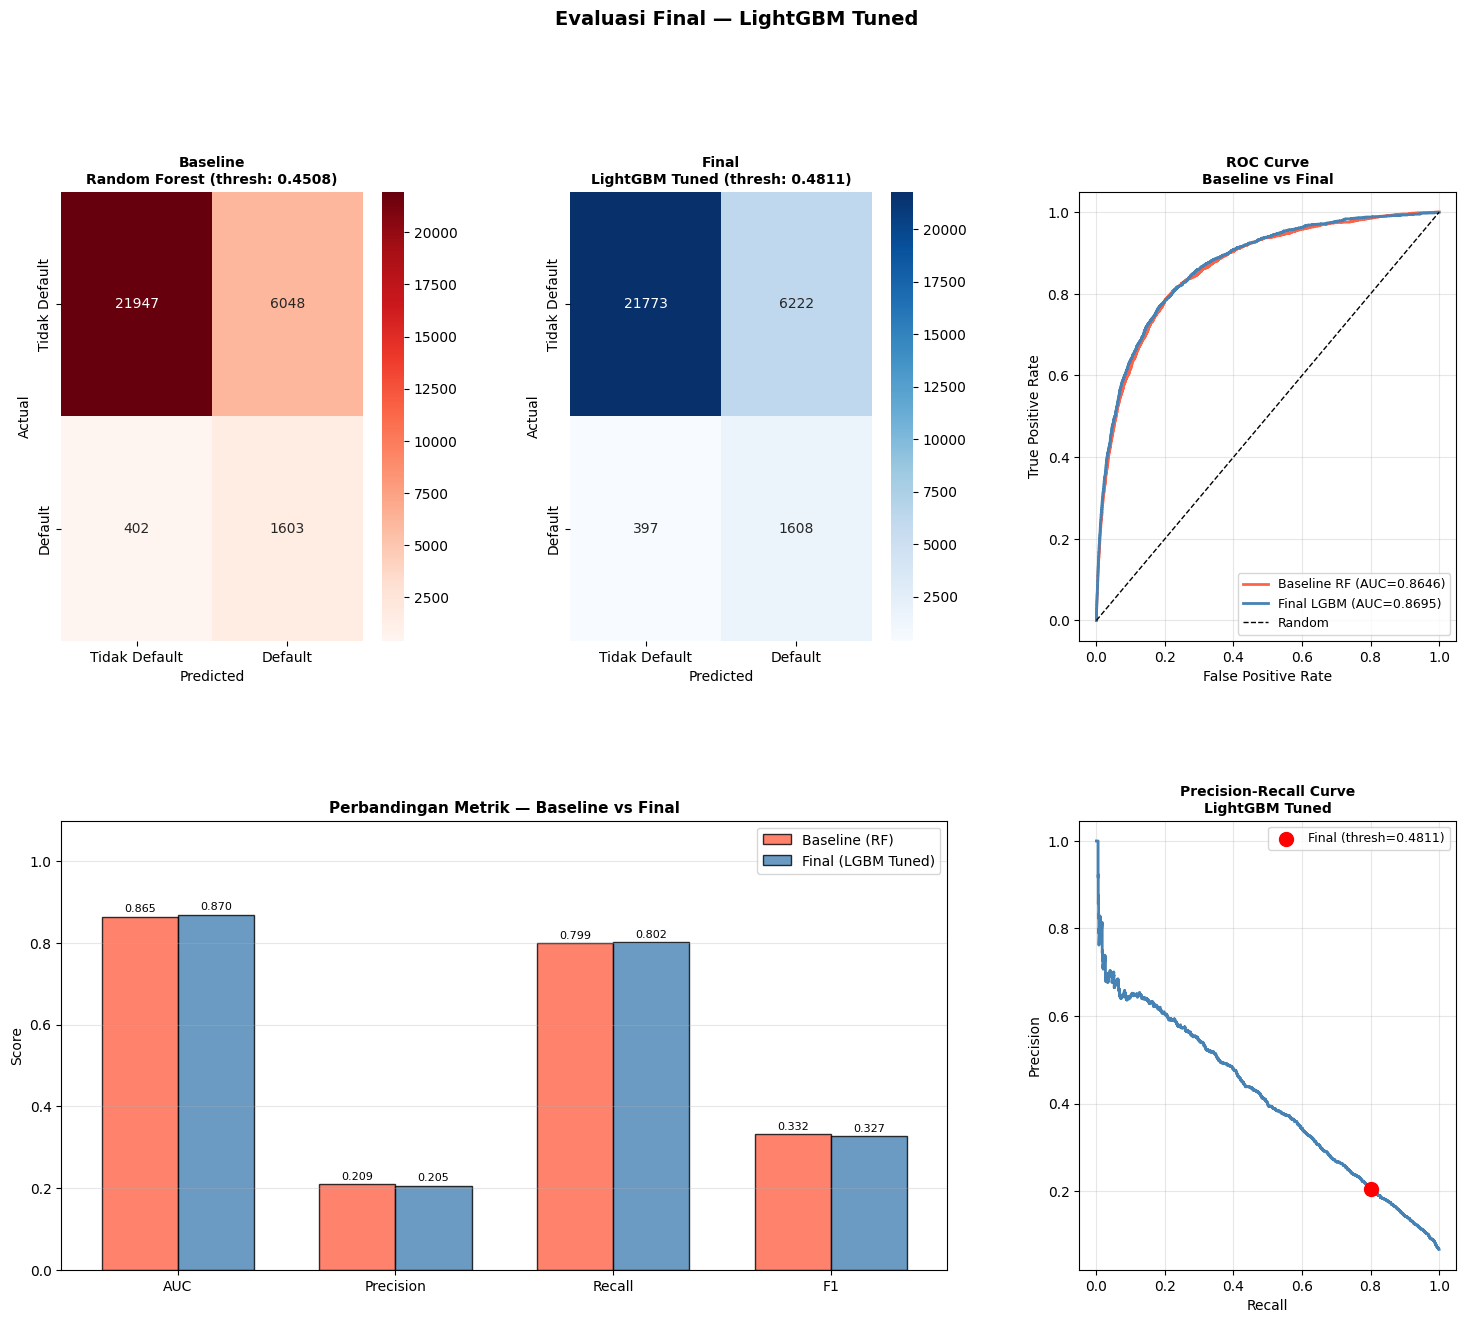

In [ ]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. Confusion Matrix Baseline vs Final ──
ax1 = fig.add_subplot(gs[0, 0])
y_pred_baseline = (roc_data['Random Forest'] >= 0.4508).astype(int)
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Reds', ax=ax1,
            xticklabels=['Tidak Default', 'Default'],
            yticklabels=['Tidak Default', 'Default'])
ax1.set_title('Baseline\nRandom Forest (thresh: 0.4508)', fontweight='bold', fontsize=10)
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')

ax2 = fig.add_subplot(gs[0, 1])
cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Tidak Default', 'Default'],
            yticklabels=['Tidak Default', 'Default'])
ax2.set_title('Final\nLightGBM Tuned (thresh: 0.4811)', fontweight='bold', fontsize=10)
ax2.set_ylabel('Actual')
ax2.set_xlabel('Predicted')

# ── 2. ROC Curve Final ──
ax3 = fig.add_subplot(gs[0, 2])
fpr_b, tpr_b, _ = roc_curve(y_test, roc_data['Random Forest'])
fpr_f, tpr_f, _ = roc_curve(y_test, y_prob_final)
ax3.plot(fpr_b, tpr_b, color='tomato',    linewidth=2,
         label=f'Baseline RF (AUC={0.8646})')
ax3.plot(fpr_f, tpr_f, color='steelblue', linewidth=2,
         label=f'Final LGBM (AUC={auc_final:.4f})')
ax3.plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve\nBaseline vs Final', fontweight='bold', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# ── 3. Bar chart perbandingan metrik ──
ax4 = fig.add_subplot(gs[1, :2])
metrics     = ['AUC', 'Precision', 'Recall', 'F1']
val_base    = [baseline[m] for m in metrics]
val_final   = [final[m]    for m in metrics]
x           = np.arange(len(metrics))
width       = 0.35
bars1 = ax4.bar(x - width/2, val_base,  width, label='Baseline (RF)',       color='tomato',    alpha=0.8, edgecolor='black')
bars2 = ax4.bar(x + width/2, val_final, width, label='Final (LGBM Tuned)', color='steelblue', alpha=0.8, edgecolor='black')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics)
ax4.set_ylim(0, 1.1)
ax4.set_ylabel('Score')
ax4.set_title('Perbandingan Metrik — Baseline vs Final', fontweight='bold', fontsize=11)
ax4.legend()
ax4.grid(alpha=0.3, axis='y')
ax4.bar_label(bars1, fmt='%.3f', fontsize=8, padding=2)
ax4.bar_label(bars2, fmt='%.3f', fontsize=8, padding=2)

# ── 4. Precision-Recall Curve Final ──
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(recalls[:-1], precisions[:-1], color='steelblue', linewidth=2)
ax5.scatter([report_final['1']['recall']], [report_final['1']['precision']],
            color='red', s=100, zorder=5,
            label=f"Final (thresh={FINAL_THRESH})")
ax5.set_xlabel('Recall')
ax5.set_ylabel('Precision')
ax5.set_title('Precision-Recall Curve\nLightGBM Tuned', fontweight='bold', fontsize=10)
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)

plt.suptitle('Evaluasi Final — LightGBM Tuned', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('evaluasi_final.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
feature_names = list(X_test_scaled.columns) if hasattr(X_test_scaled, 'columns') else X.columns.tolist()
print(feature_names)

['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'TotalLatePayments', 'AgeGroup', 'IncomePerDependent']



Menghitung SHAP values...


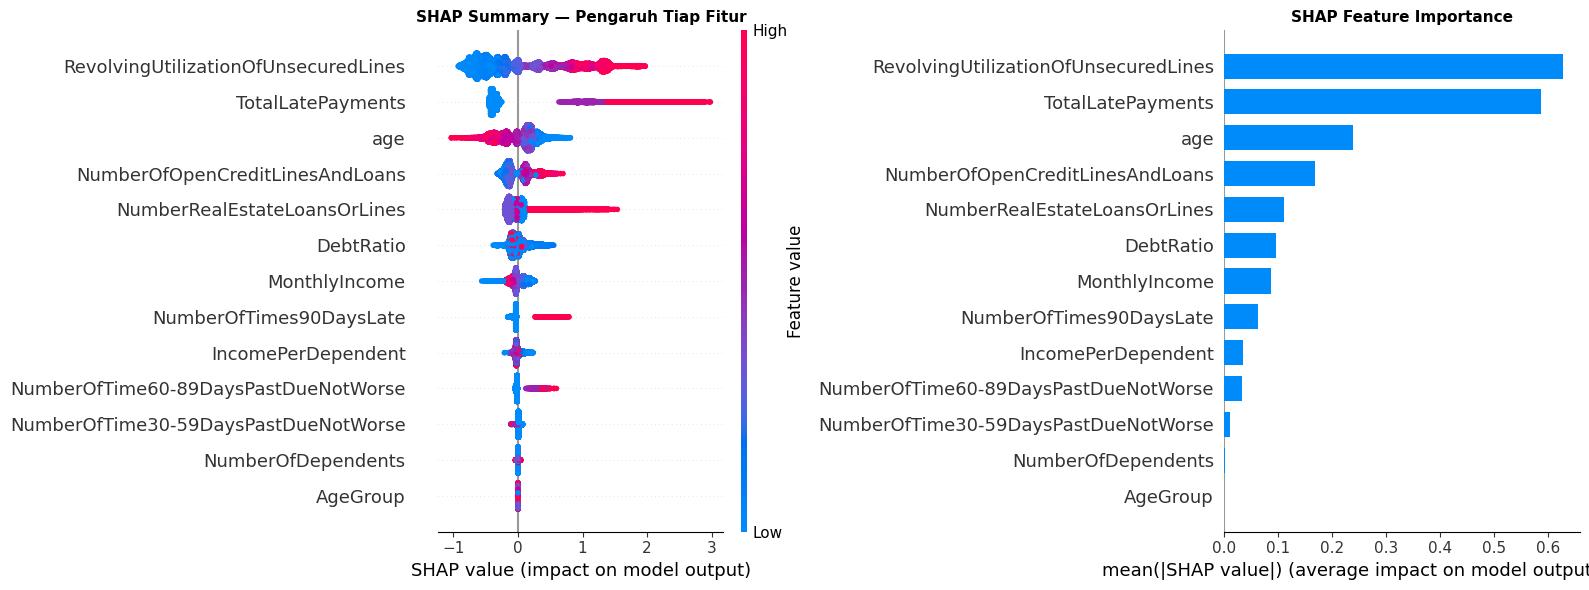

In [ ]:
import shap

print("\nMenghitung SHAP values...")
explainer   = shap.TreeExplainer(tuned_results['LightGBM']['model'])
shap_values = explainer.shap_values(X_test_scaled)

# Kalau output shap_values berbentuk list (binary classification), ambil index 1
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Beeswarm (summary plot) ──
plt.sca(axes[0])
shap.summary_plot(sv, X_test_scaled,
                  feature_names=feature_names,
                  show=False, plot_size=None)
axes[0].set_title('SHAP Summary — Pengaruh Tiap Fitur',
                  fontweight='bold', fontsize=11)

# ── Bar chart importance ──
plt.sca(axes[1])
shap.summary_plot(sv, X_test_scaled,
                  feature_names=feature_names,
                  plot_type='bar', show=False, plot_size=None)
axes[1].set_title('SHAP Feature Importance',
                  fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import joblib
import json
from google.colab import files

FINAL_MODEL = tuned_results['LightGBM']['model']

joblib.dump(FINAL_MODEL, 'lightgbm_final.pkl')
joblib.dump(scaler, 'scaler_final.pkl')

with open('model_metadata.json', 'w') as f:
    json.dump({'threshold': 0.4811, 'feature_names': feature_names}, f, indent=4)

files.download('lightgbm_final.pkl')
files.download('scaler_final.pkl')
files.download('model_metadata.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **6. Kesimpulan**

Penelitian ini berhasil membangun model prediksi gagal bayar kredit menggunakan LightGBM dengan optimasi Optuna pada dataset Give Me Some Credit (150.000 record). Berikut kesimpulan utama:

### 6.1 Performa Model

| Model | AUC-ROC | Recall | Precision | F1-Score |
|---|---|---|---|---|
| Logistic Regression | 0,8556 | 0,7576 | 0,2042 | 0,3217 |
| Decision Tree | 0,8526 | 0,6978 | 0,2441 | 0,3617 |
| Random Forest | 0,8646 | 0,7312 | 0,2438 | 0,3657 |
| XGBoost | 0,8624 | 0,7382 | 0,2406 | 0,3629 |
| **LightGBM Tuned** | **0,8695** | **0,8329** | **0,1838** | **0,3027** |

### 6.2 Model Final: LightGBM Tuned (Optuna)
- **AUC-ROC**: 0,8695 (test) · 0,8721 (train) → Gap: 0,0025 ✅ tidak overfit
- **Threshold optimal**: 0,4811 (berdasarkan Recall ≥ 0,80)
- **SMOTE**: Sebelum 111.979 vs 8.021 → Sesudah 111.979 vs 111.979

### 6.3 Feature Importance (SHAP)
Tiga fitur paling berpengaruh:
1. `RevolvingUtilizationOfUnsecuredLines` — rasio penggunaan kredit bergulir
2. `TotalLatePayments` — total riwayat keterlambatan (feature engineering)
3. `age` — usia nasabah

### 6.4 Penanganan Imbalanced Data
SMOTE diterapkan hanya pada data training (hindari data leakage). Distribusi awal sangat tidak seimbang: **93,32% tidak default vs 6,68% default** (rasio 1:14). Recall meningkat signifikan setelah SMOTE dan threshold tuning.

### 6.5 Limitasi
- F1-score 0,3027 merupakan konsekuensi optimasi recall pada data sangat tidak seimbang
- Precision rendah (0,1838) dapat ditoleransi jika biaya investigasi < biaya kredit macet
- Model perlu diretrain berkala menggunakan data terbaru